# **Système de Recommandation LightGCN**


## **_Phase 1 :_** _Préparation et Exploration des Données_

> ### Dataset : MovieLens ml-latest-small

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch


# Configuration globale 
warnings.filterwarnings('ignore') # Masquer les erreurs d'avertissement

sns.set_theme(style="whitegrid") # Style de tous les graphiques Seaborn
plt.rcParams['figure.figsize'] = (12, 5) # Taille de tousl les graphiques matplotlib

SEED = 42 # Valeur qui sert à fixer le génératuer de nombres aléatoires
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device : {DEVICE}")
print(f"GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"PyTorch : {torch.__version__}")
print("Imports OK!")

Device    : cuda
GPU       : Quadro M3000M
PyTorch   : 2.3.0+cu121
Imports OK!


## 1. Chargement des données

In [12]:
# Chemin
DATA_PATH = '../data/ml-latest-small/'

# Chargement des fichiers CSV 
ratings = pd.read_csv(os.path.join(DATA_PATH, 'ratings.csv'))
movies  = pd.read_csv(os.path.join(DATA_PATH, 'movies.csv'))
tags    = pd.read_csv(os.path.join(DATA_PATH, 'tags.csv'))

# Aperçu rapide 
print(" RATINGS ")
print(f"Shape : {ratings.shape}")
print(f"Colonnes : {list(ratings.columns)}")
print(f"Mémoire : {ratings.memory_usage(deep=True).sum() / 1024:.1f} KB")
print()
print(" MOVIES ")
print(f"Shape : {movies.shape}")
print(f"Colonnes : {list(movies.columns)}")
print()
print(" TAGS ")
print(f"Shape : {tags.shape}")
print(f"Colonnes : {list(tags.columns)}")
print()
print(ratings.head())

 RATINGS 
Shape : (100836, 4)
Colonnes : ['userId', 'movieId', 'rating', 'timestamp']
Mémoire : 3151.3 KB

 MOVIES 
Shape : (9742, 3)
Colonnes : ['movieId', 'title', 'genres']

 TAGS 
Shape : (3683, 4)
Colonnes : ['userId', 'movieId', 'tag', 'timestamp']

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


## 2. Statistiques descriptives

In [18]:
n_users  = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
density  = n_ratings / (n_users * n_movies) * 100
sparsity = 100 - density

print("STATISTIQUES GENERALES \n")

print(f"Nombre d'utilisateurs : {n_users:,}")
print(f"Nombre de films : {n_movies:,}")
print(f"Nombre de notes : {n_ratings:,}")
print(f"Note minimale : {ratings['rating'].min()}")
print(f"Note maximale : {ratings['rating'].max()}")
print(f"Note moyenne : {ratings['rating'].mean():.2f}")
print(f"Note mediane : {ratings['rating'].median():.1f}")

print(f"Densite du graphe : {density:.2f}%")
print(f"Sparsite du graphe : {sparsity:.2f}%")


STATISTIQUES GENERALES 

Nombre d'utilisateurs : 610
Nombre de films : 9,724
Nombre de notes : 100,836
Note minimale : 0.5
Note maximale : 5.0
Note moyenne : 3.50
Note mediane : 3.5
Densite du graphe : 1.70%
Sparsite du graphe : 98.30%


## 3. Analyse exploratoire (EDA)
### _3.1 Distribution des notes_

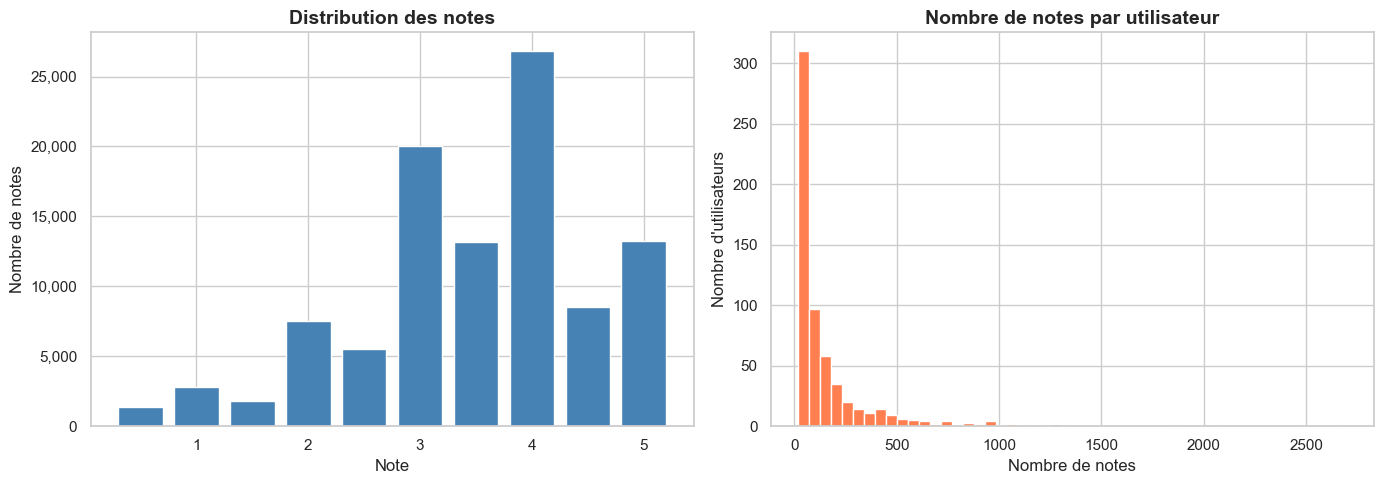

Notes par utilisateur :    Min : 20    Max : 2698    Moyenne : 165.3


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : distribution des notes 
rating_counts = ratings['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, 
            width=0.4, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution des notes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Note')
axes[0].set_ylabel('Nombre de notes')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Graphique 2 : notes par utilisateur 
notes_par_user = ratings.groupby('userId')['rating'].count()
axes[1].hist(notes_par_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Nombre de notes par utilisateur', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de notes')
axes[1].set_ylabel('Nombre d\'utilisateurs')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/distribution_notes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Notes par utilisateur :    Min : {notes_par_user.min()}    Max : {notes_par_user.max()}    Moyenne : {notes_par_user.mean():.1f}")

### _3.2 Distribution des films_

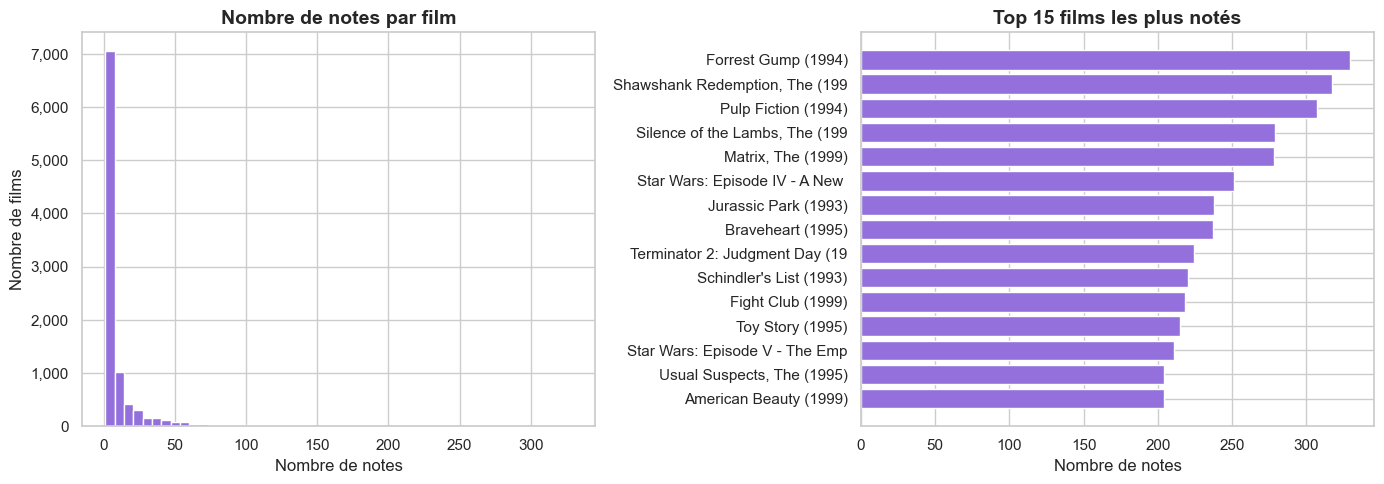

Notes par film :     Min : 1    Max : 329    Moyenne : 10.4


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : notes par film 
notes_par_film = ratings.groupby('movieId')['rating'].count()
axes[0].hist(notes_par_film, bins=50, color='mediumpurple', edgecolor='white')
axes[0].set_title('Nombre de notes par film', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Nombre de notes')
axes[0].set_ylabel('Nombre de films')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Graphique 2 : Top 15 films les plus notés 
top_films = notes_par_film.sort_values(ascending=False).head(15)
top_films_df = top_films.reset_index()
top_films_df = top_films_df.merge(movies[['movieId', 'title']], on='movieId')
top_films_df['title'] = top_films_df['title'].str[:30]

axes[1].barh(top_films_df['title'][::-1], top_films_df['rating'][::-1],
             color='mediumpurple', edgecolor='white')
axes[1].set_title('Top 15 films les plus notés', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de notes')

plt.tight_layout()
plt.savefig('../data/distribution_films.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Notes par film :     Min : {notes_par_film.min()}    Max : {notes_par_film.max()}    Moyenne : {notes_par_film.mean():.1f}")

### _3.3 Analyse temporelle_

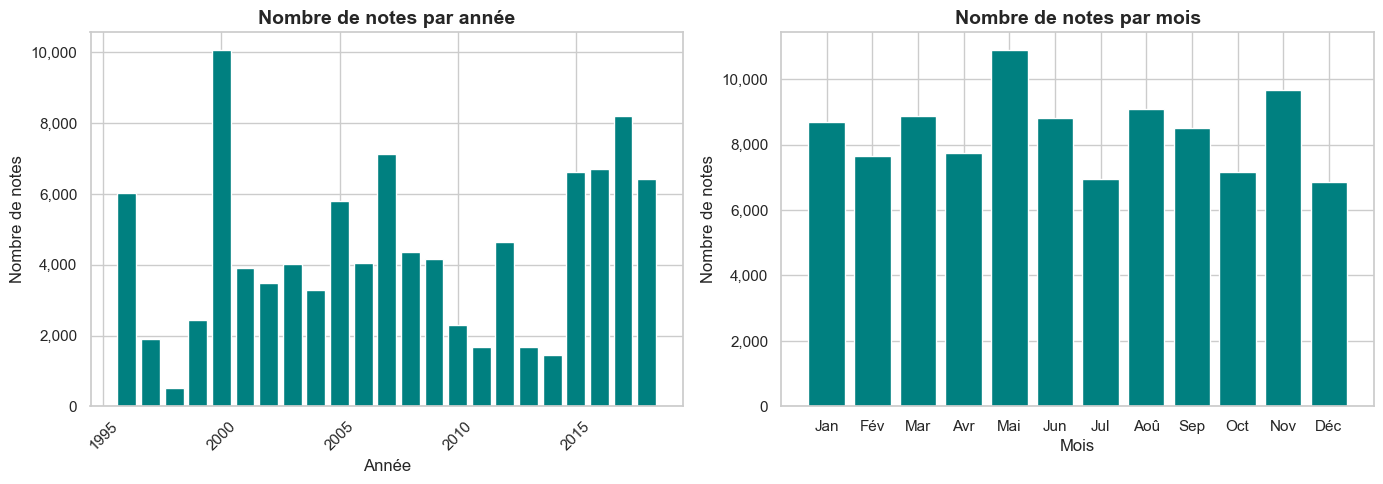

Période couverte : 1996 -> 2018


In [22]:
# Conversion timestamp 
ratings['date'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year'] = ratings['date'].dt.year
ratings['month'] = ratings['date'].dt.month

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : notes par année 
notes_par_annee = ratings.groupby('year').size()
axes[0].bar(notes_par_annee.index, notes_par_annee.values,
            color='teal', edgecolor='white')
axes[0].set_title('Nombre de notes par année', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de notes')
axes[0].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=45)

# Graphique 2 : notes par mois 
notes_par_mois = ratings.groupby('month').size()
mois_labels = ['Jan','Fév','Mar','Avr','Mai','Jun',
               'Jul','Aoû','Sep','Oct','Nov','Déc']
axes[1].bar(mois_labels, notes_par_mois.values,
            color='teal', edgecolor='white')
axes[1].set_title('Nombre de notes par mois', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de notes')
axes[1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('../data/analyse_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Période couverte : {ratings['year'].min()} -> {ratings['year'].max()}")

## 4. Nettoyage et filtrage des données

In [23]:
print(" AVANT FILTRAGE")
print(f"Utilisateurs : {ratings['userId'].nunique():,}")
print(f"Films: {ratings['movieId'].nunique():,}")
print(f"Interactions : {len(ratings):,}")

# Seuil minimal : utilisateurs >= 20 notes, films >= 5 notes 
MIN_USER_RATINGS = 20
MIN_MOVIE_RATINGS = 5

# Filtrage itératif jusqu'à stabilisation
df = ratings[['userId', 'movieId', 'rating']].copy()
prev_len = -1

while prev_len != len(df):
    prev_len = len(df)
    # Filtre utilisateurs
    user_counts = df['userId'].value_counts()
    df = df[df['userId'].isin(user_counts[user_counts >= MIN_USER_RATINGS].index)]
    # Filtre films
    movie_counts = df['movieId'].value_counts()
    df = df[df['movieId'].isin(movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index)]

print("\n APRES FILTRAGE ")
print(f"Utilisateurs : {df['userId'].nunique():,}")
print(f"Films : {df['movieId'].nunique():,}")
print(f"Interactions : {len(df):,}")
print(f"\nInteractions supprimees : {len(ratings) - len(df):,}")
print(f"Taux de conservation : {len(df)/len(ratings)*100:.1f}%")

 AVANT FILTRAGE
Utilisateurs : 610
Films: 9,724
Interactions : 100,836

 APRES FILTRAGE 
Utilisateurs : 602
Films : 3,643
Interactions : 90,109

Interactions supprimees : 10,727
Taux de conservation : 89.4%


## 5. Réindexation des utilisateurs et des films

> Réindexation continue à partir de 0 

LightGCN a besoin d'indices continus 0, 1, 2, ... mais les `userId` et `movieId` originaux ont des trous après filtrage

In [ ]:
# Liste triée de tous les utilisateurs et films uniques
unique_users  = sorted(df['userId'].unique())
unique_movies = sorted(df['movieId'].unique())

# Dictionnaires de mapping : ID original -> index continu (0, 1, 2, ...)
user2idx  = {u: i for i, u in enumerate(unique_users)}
movie2idx = {m: i for i, m in enumerate(unique_movies)}

# Dictionnaires inverses : index continu -> ID original
idx2user  = {i: u for u, i in user2idx.items()}
idx2movie = {i: m for m, i in movie2idx.items()}

# Application des mappings sur le dataframe
df['user_idx']  = df['userId'].map(user2idx)
df['movie_idx'] = df['movieId'].map(movie2idx)

# Stockage des dimensions du graphe
n_users  = len(unique_users)
n_movies = len(unique_movies)
n_interactions = len(df)

print(f"Nombre d'utilisateurs  : {n_users}")
print(f"Nombre de films: {n_movies}")
print(f"Nombre d'interactions  : {n_interactions:,}")
print(f"\nuser_idx  : {df['user_idx'].min()} -> {df['user_idx'].max()}")
print(f"movie_idx : {df['movie_idx'].min()} -> {df['movie_idx'].max()}")
print("\nApercu :")
print(df[['userId','user_idx','movieId','movie_idx','rating']].head())

Nombre d'utilisateurs  : 602
Nombre de films: 3643
Nombre d'interactions  : 90,109

user_idx  : 0 -> 601
movie_idx : 0 -> 3642

Apercu :
    userId  user_idx  movieId  movie_idx  rating
0        1         0        1          0     4.0
1        1         0        3          2     4.0
2        1         0        6          5     4.0
3        1         0       47         40     5.0
4        1         0       50         42     5.0
5        1         0       70         54     3.0
6        1         0      101         75     5.0
7        1         0      110         80     4.0
8        1         0      151         94     5.0
9        1         0      157         98     5.0
10       1         0      163        104     5.0
11       1         0      216        136     5.0
12       1         0      223        140     3.0
13       1         0      231        146     5.0
14       1         0      235        150     4.0
15       1         0      260        167     5.0
16       1         0      296 

## 6. Split temporel train / validation / test

> On trie les interactions de chaque utilisateur par date.

Les plus anciennes -> train, les plus récentes -> test. Cela simule un vrai scénario : on prédit le futur à partir du passé

In [28]:
# Tri par timestamp pour respecter la temporalité
df_sorted = df.merge(
    ratings[['userId', 'movieId', 'timestamp']],
    on=['userId', 'movieId'],
    how='left'
).sort_values(['user_idx', 'timestamp'])

# Split par utilisateur : 80% train / 10% val / 10% test 
train_data = []
val_data   = []
test_data  = []

for user_idx, group in df_sorted.groupby('user_idx'):
    n= len(group)
    n_train= max(1, int(0.8 * n))
    n_val= max(1, int(0.1 * n))

    train_data.append(group.iloc[:n_train])
    val_data.append(group.iloc[n_train:n_train + n_val])
    test_data.append(group.iloc[n_train + n_val:])

train_df = pd.concat(train_data).reset_index(drop=True)
val_df= pd.concat(val_data).reset_index(drop=True)
test_df = pd.concat(test_data).reset_index(drop=True)

# Résumé 
total = len(train_df) + len(val_df) + len(test_df)
print(" SPLIT TRAIN / VAL / TEST \n")
print(f"Train : {len(train_df):,}  ({len(train_df)/total*100:.1f}%)")
print(f"Val: {len(val_df):,}  ({len(val_df)/total*100:.1f}%)")
print(f"Test : {len(test_df):,}  ({len(test_df)/total*100:.1f}%)")
print(f"Total : {total:,}")
print(f"\nVerification : {total == len(df)}")

 SPLIT TRAIN / VAL / TEST 

Train : 71,842  (79.7%)
Val: 8,761  (9.7%)
Test : 9,506  (10.5%)
Total : 90,109

Verification : True


## 7. Construction du graphe biparti utilisateur-film

> On utilise uniquement le train pour construire le graphe.

Val et test servent uniquement à l'évaluation

> Matrice creuse utilisateur x film (1 = interaction, 0 = pas d'interaction)

In [29]:
# Construction de la matrice d'interaction
row = train_df['user_idx'].values   # indices utilisateurs
col = train_df['movie_idx'].values  # indices films
data = np.ones(len(train_df))       # 1 pour chaque interaction

# Matrice creuse de taille (n_users x n_movies)
interaction_matrix = csr_matrix(
    (data, (row, col)),
    shape=(n_users, n_movies)
)

print(" MATRICE D'INTERACTION ")
print(f"Dimensions: {interaction_matrix.shape}")
print(f"Interactions: {interaction_matrix.nnz:,}")
print(f"Densite: {interaction_matrix.nnz / (n_users * n_movies) * 100:.2f}%")
print(f"Type: {type(interaction_matrix)}")

#  Dictionnaire train : user -> set de films vus 
# Utilisé pendant l'entraînement pour l'échantillonnage négatif
train_user_items = {}
for _, row_data in train_df.iterrows():
    u = int(row_data['user_idx'])
    m = int(row_data['movie_idx'])
    if u not in train_user_items:
        train_user_items[u] = set()
    train_user_items[u].add(m)

# Dictionnaire test : user -> set de films à prédire
test_user_items = {}
for _, row_data in test_df.iterrows():
    u = int(row_data['user_idx'])
    m = int(row_data['movie_idx'])
    if u not in test_user_items:
        test_user_items[u] = set()
    test_user_items[u].add(m)

print(f"\nUtilisateurs dans train_user_items : {len(train_user_items)}")
print(f"Utilisateurs dans test_user_items  : {len(test_user_items)}")
print(f"\nExemple: L' utilisateur 0 a vu {len(train_user_items[0])} films dans le trainset")

 MATRICE D'INTERACTION 
Dimensions: (602, 3643)
Interactions: 71,842
Densite: 3.28%
Type: <class 'scipy.sparse._csr.csr_matrix'>

Utilisateurs dans train_user_items : 602
Utilisateurs dans test_user_items  : 602

Exemple: L' utilisateur 0 a vu 181 films dans le trainset


## 8. Sauvegarde des données préprocessées

In [30]:
import pickle

# Sauvegarde des dataframes
train_df.to_csv('../data/train.csv', index=False)
val_df.to_csv('../data/val.csv', index=False)
test_df.to_csv('../data/test.csv', index=False)

# Sauvegarde des mappings et dictionnaires
preprocessed = {
    'n_users' : n_users,
    'n_movies' : n_movies,
    'user2idx' : user2idx,
    'movie2idx' : movie2idx,
    'idx2user' : idx2user,
    'idx2movie' : idx2movie,
    'train_user_items' : train_user_items,
    'test_user_items' : test_user_items,
}

with open('../data/preprocessed.pkl', 'wb') as f:
    pickle.dump(preprocessed, f)

# Sauvegarde de la matrice d'interaction 
from scipy.sparse import save_npz
save_npz('../data/interaction_matrix.npz', interaction_matrix)

# Vérification 
fichiers = ['train.csv', 'val.csv', 'test.csv',
            'preprocessed.pkl', 'interaction_matrix.npz']

print(" FICHIERS SAUVEGARDES ")
for f in fichiers:
    path = f'../data/{f}'
    size = os.path.getsize(path) / 1024
    print(f" {f:<30} {size:.1f} KB")

print("\nSauvegarde OK ")

 FICHIERS SAUVEGARDES 
 train.csv                      2303.8 KB
 val.csv                        283.4 KB
 test.csv                       308.8 KB
 preprocessed.pkl               359.2 KB
 interaction_matrix.npz         139.4 KB

Sauvegarde OK 
